### Objective:
##### The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Preparation:

In [2]:
data = pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


### 2. Exploratory Data Analysis (EDA):

In [3]:
data.shape

(908, 13)

In [4]:
data.describe

<bound method NDFrame.describe of      age   sex               cp  trestbps  chol    fbs           restecg  \
0     63  Male   typical angina       145   233   True    lv hypertrophy   
1     41  Male  atypical angina       135   203  False            normal   
2     57  Male     asymptomatic       140   192  False            normal   
3     52  Male   typical angina       118   186  False    lv hypertrophy   
4     57  Male     asymptomatic       110   201  False            normal   
..   ...   ...              ...       ...   ...    ...               ...   
903   53  Male     asymptomatic       125     0  False            normal   
904   62  Male     asymptomatic       166   170  False  st-t abnormality   
905   56  Male      non-anginal       170     0  False    lv hypertrophy   
906   56  Male      non-anginal       144   208   True  st-t abnormality   
907   57  Male     asymptomatic       142   277   True  st-t abnormality   

     thalch  exang  oldpeak        slope             

In [5]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


#### Check for missing values

In [7]:
data.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [8]:
data.fillna(data['oldpeak'].mean(),inplace=True)

In [9]:
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [10]:
data['exang'] = data['exang'].replace({'TRUE':True,'FALSE':False,'True':True,'False':False})
data['exang'] = data['exang'].astype(str)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [12]:
data.duplicated().sum()

np.int64(1)

In [13]:
data.drop_duplicates(ignore_index=True,inplace=True)

In [14]:
data.duplicated().sum()

np.int64(0)

### 3. Feature Engineering:

In [15]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

In [16]:
data['sex'] = data['sex'].astype(str)
data['cp'] = data['cp'].astype(str)
data['fbs'] = data['fbs'].astype(str)
data['restecg'] = data['restecg'].astype(str)
data['exang'] = data['exang'].astype(str)
data['slope'] = data['slope'].astype(str)
data['thal'] = data['thal'].astype(str)

# Now apply Label Encoding
data['sex'] = le.fit_transform(data['sex'])
data['cp'] = le.fit_transform(data['cp'])
data['fbs'] = le.fit_transform(data['fbs'])
data['restecg'] = le.fit_transform(data['restecg'])
data['exang'] = le.fit_transform(data['exang'])
data['slope'] = le.fit_transform(data['slope'])
data['thal'] = le.fit_transform(data['thal'])
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.300000,0,0,0
1,41,1,1,135,203,0,1,132,0,0.000000,1,0,0
2,57,1,0,140,192,0,1,148,0,0.400000,1,0,0
3,52,1,3,118,186,0,0,190,0,0.000000,1,0,0
4,57,1,0,110,201,0,1,126,2,1.500000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,1,0,125,0,0,1,120,0,1.500000,2,2,4
903,62,1,0,166,170,0,2,120,2,3.000000,1,2,4
904,56,1,2,170,0,0,0,123,2,2.500000,0,1,4
905,56,1,2,144,208,1,2,105,1,0.891253,0,0,4


In [17]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,53.787211,0.790518,0.776185,133.412348,201.465270,0.203969,0.990077,135.976847,0.780595,0.892236,1.156560,1.187431,1.007718
std,9.162016,0.407163,0.958041,20.405432,112.158285,0.403169,0.634643,26.813075,0.955603,1.055993,0.690337,0.735520,1.144594
min,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000
25%,47.500000,1.000000,0.000000,120.000000,176.500000,0.000000,1.000000,118.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,224.000000,0.000000,1.000000,138.000000,0.000000,0.800000,1.000000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,144.000000,270.000000,0.000000,1.000000,156.000000,2.000000,1.500000,2.000000,2.000000,2.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,2.000000,6.200000,2.000000,2.000000,4.000000


In [18]:
data.corr(numeric_only=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
age,1.000000,0.051947,-0.068305,0.253709,-0.100059,0.177004,-0.008336,-0.327868,0.171408,0.233265,-0.053886,0.058829,0.326227
sex,0.051947,1.000000,-0.125986,0.015988,-0.191632,0.092480,0.077376,-0.178484,0.173932,0.101743,-0.044191,0.068596,0.259258
cp,-0.068305,-0.125986,1.000000,0.007944,0.071005,-0.044562,-0.074455,0.249440,-0.361130,-0.169497,0.094762,-0.079809,-0.314480
trestbps,0.253709,0.015988,0.007944,1.000000,0.117392,0.112124,0.056824,-0.132841,0.124476,0.153034,0.008262,0.056620,0.136581
chol,-0.100059,-0.191632,0.071005,0.117392,1.000000,-0.113651,-0.195021,0.198074,-0.039580,0.028901,0.047655,-0.016900,-0.239065
fbs,0.177004,0.092480,-0.044562,0.112124,-0.113651,1.000000,0.068311,-0.065827,0.007420,0.022296,-0.027616,-0.017400,0.156839
restecg,-0.008336,0.077376,-0.074455,0.056824,-0.195021,0.068311,1.000000,-0.194343,0.054645,-0.030135,-0.082107,-0.111874,0.035053
thalch,-0.327868,-0.178484,0.249440,-0.132841,0.198074,-0.065827,-0.194343,1.000000,-0.323838,-0.129435,0.223212,0.005985,-0.322632
exang,0.171408,0.173932,-0.361130,0.124476,-0.039580,0.007420,0.054645,-0.323838,1.000000,0.382292,-0.158688,0.099402,0.358778
oldpeak,0.233265,0.101743,-0.169497,0.153034,0.028901,0.022296,-0.030135,-0.129435,0.382292,1.000000,-0.186815,0.090359,0.417724


### Data Visualization

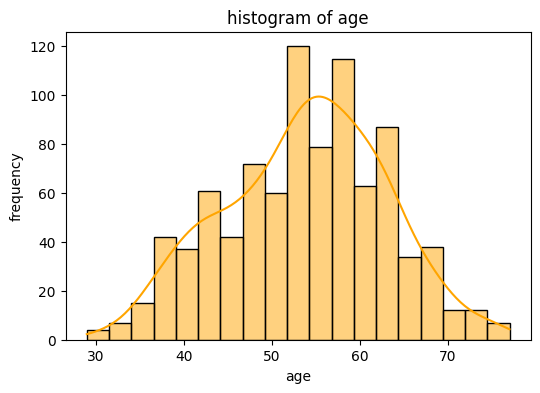

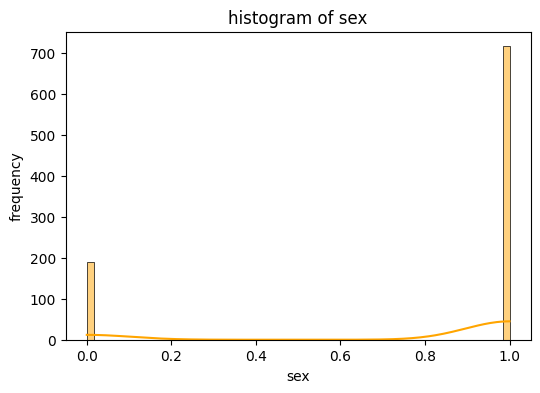

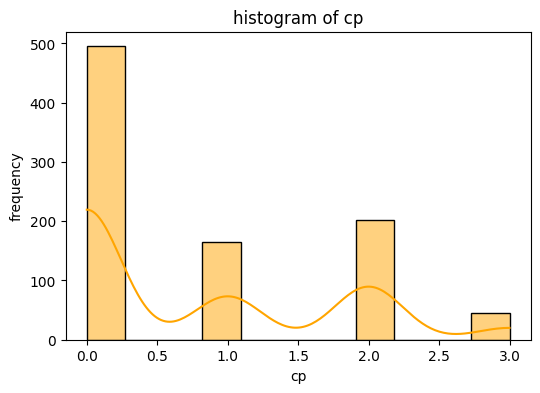

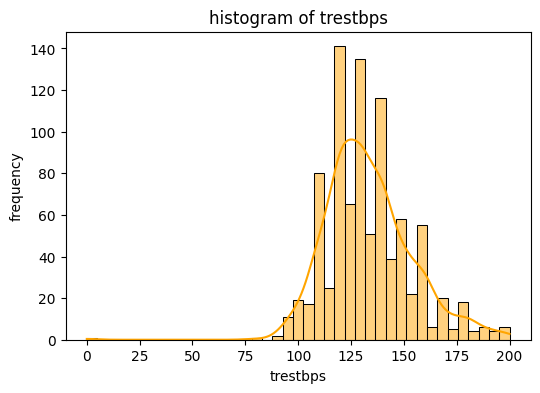

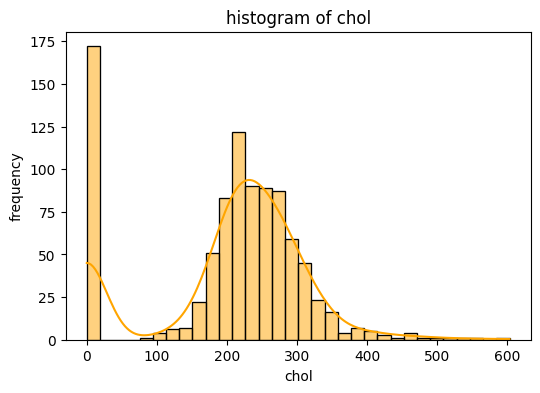

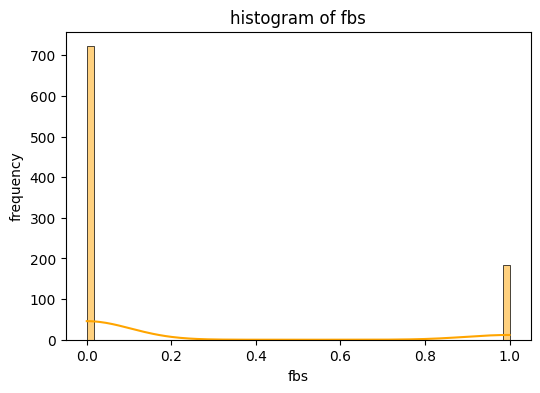

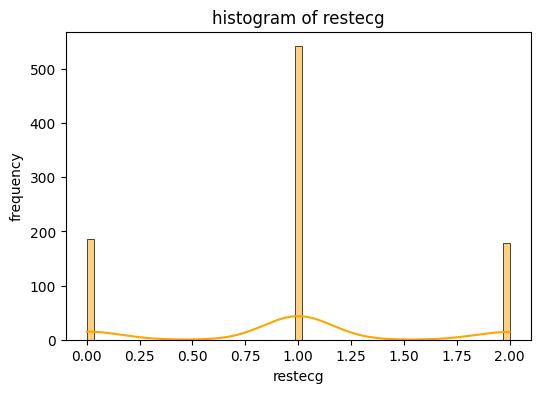

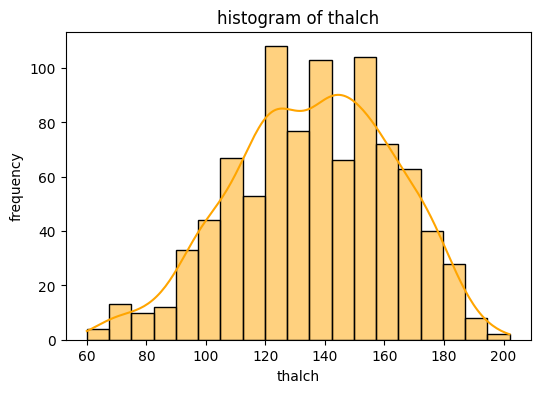

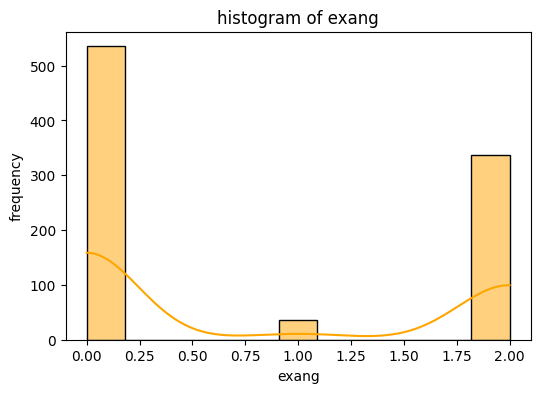

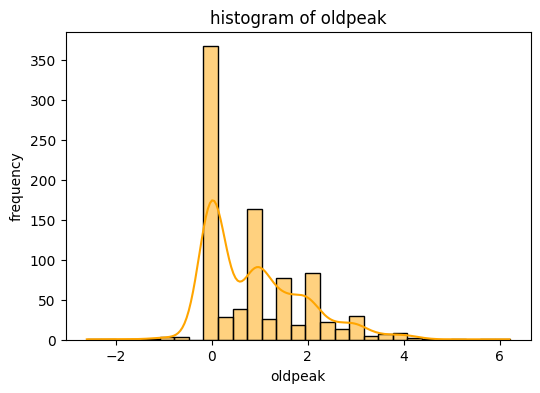

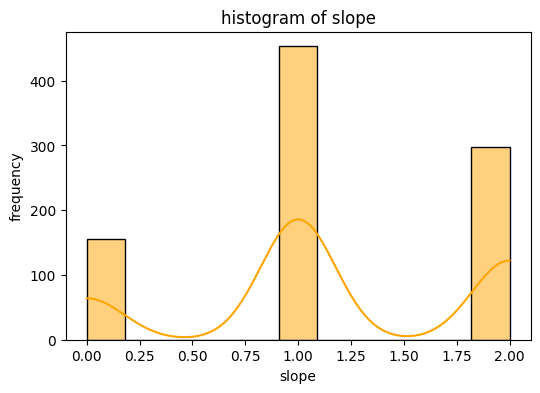

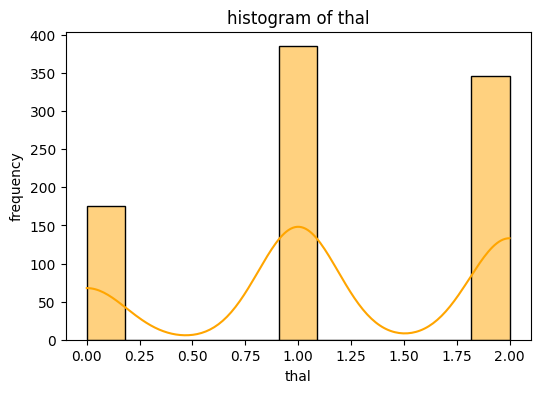

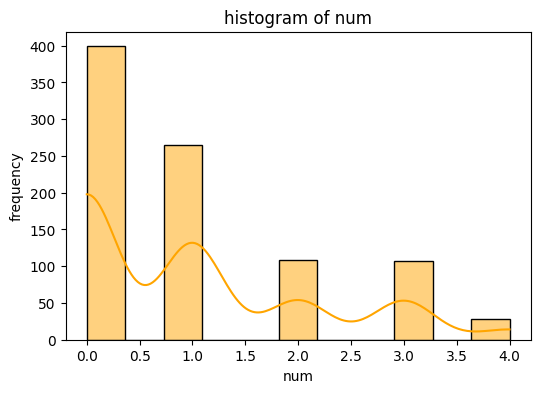

In [19]:
#creating histogram

for col in data.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True,color='orange',edgecolor='black')
    plt.title(f'histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

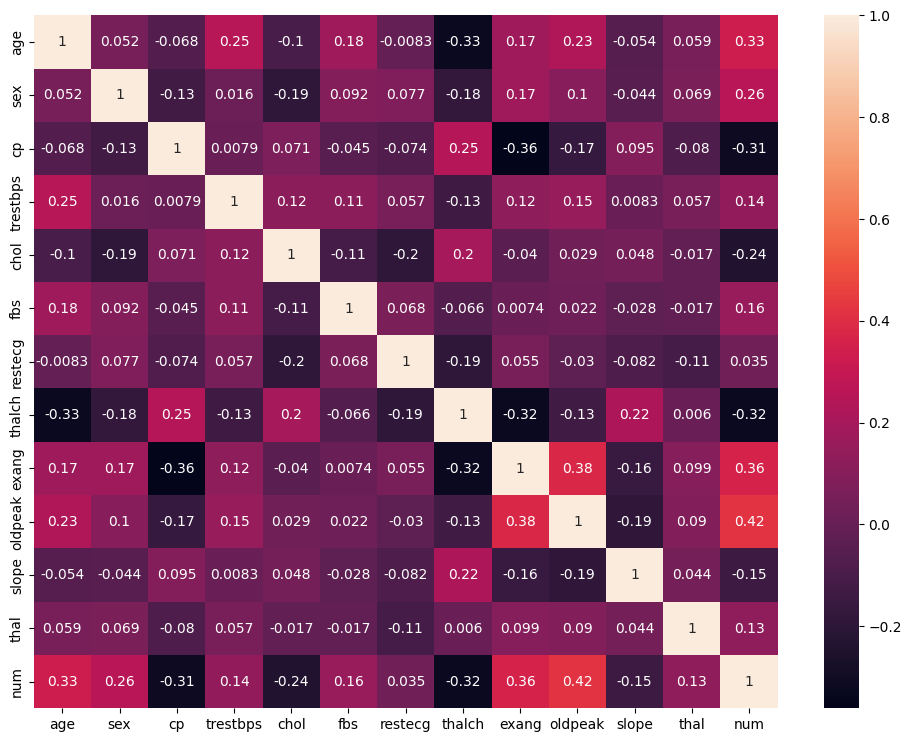

In [20]:
#correlation heatmap

plt.figure(figsize=(12,9))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.show()

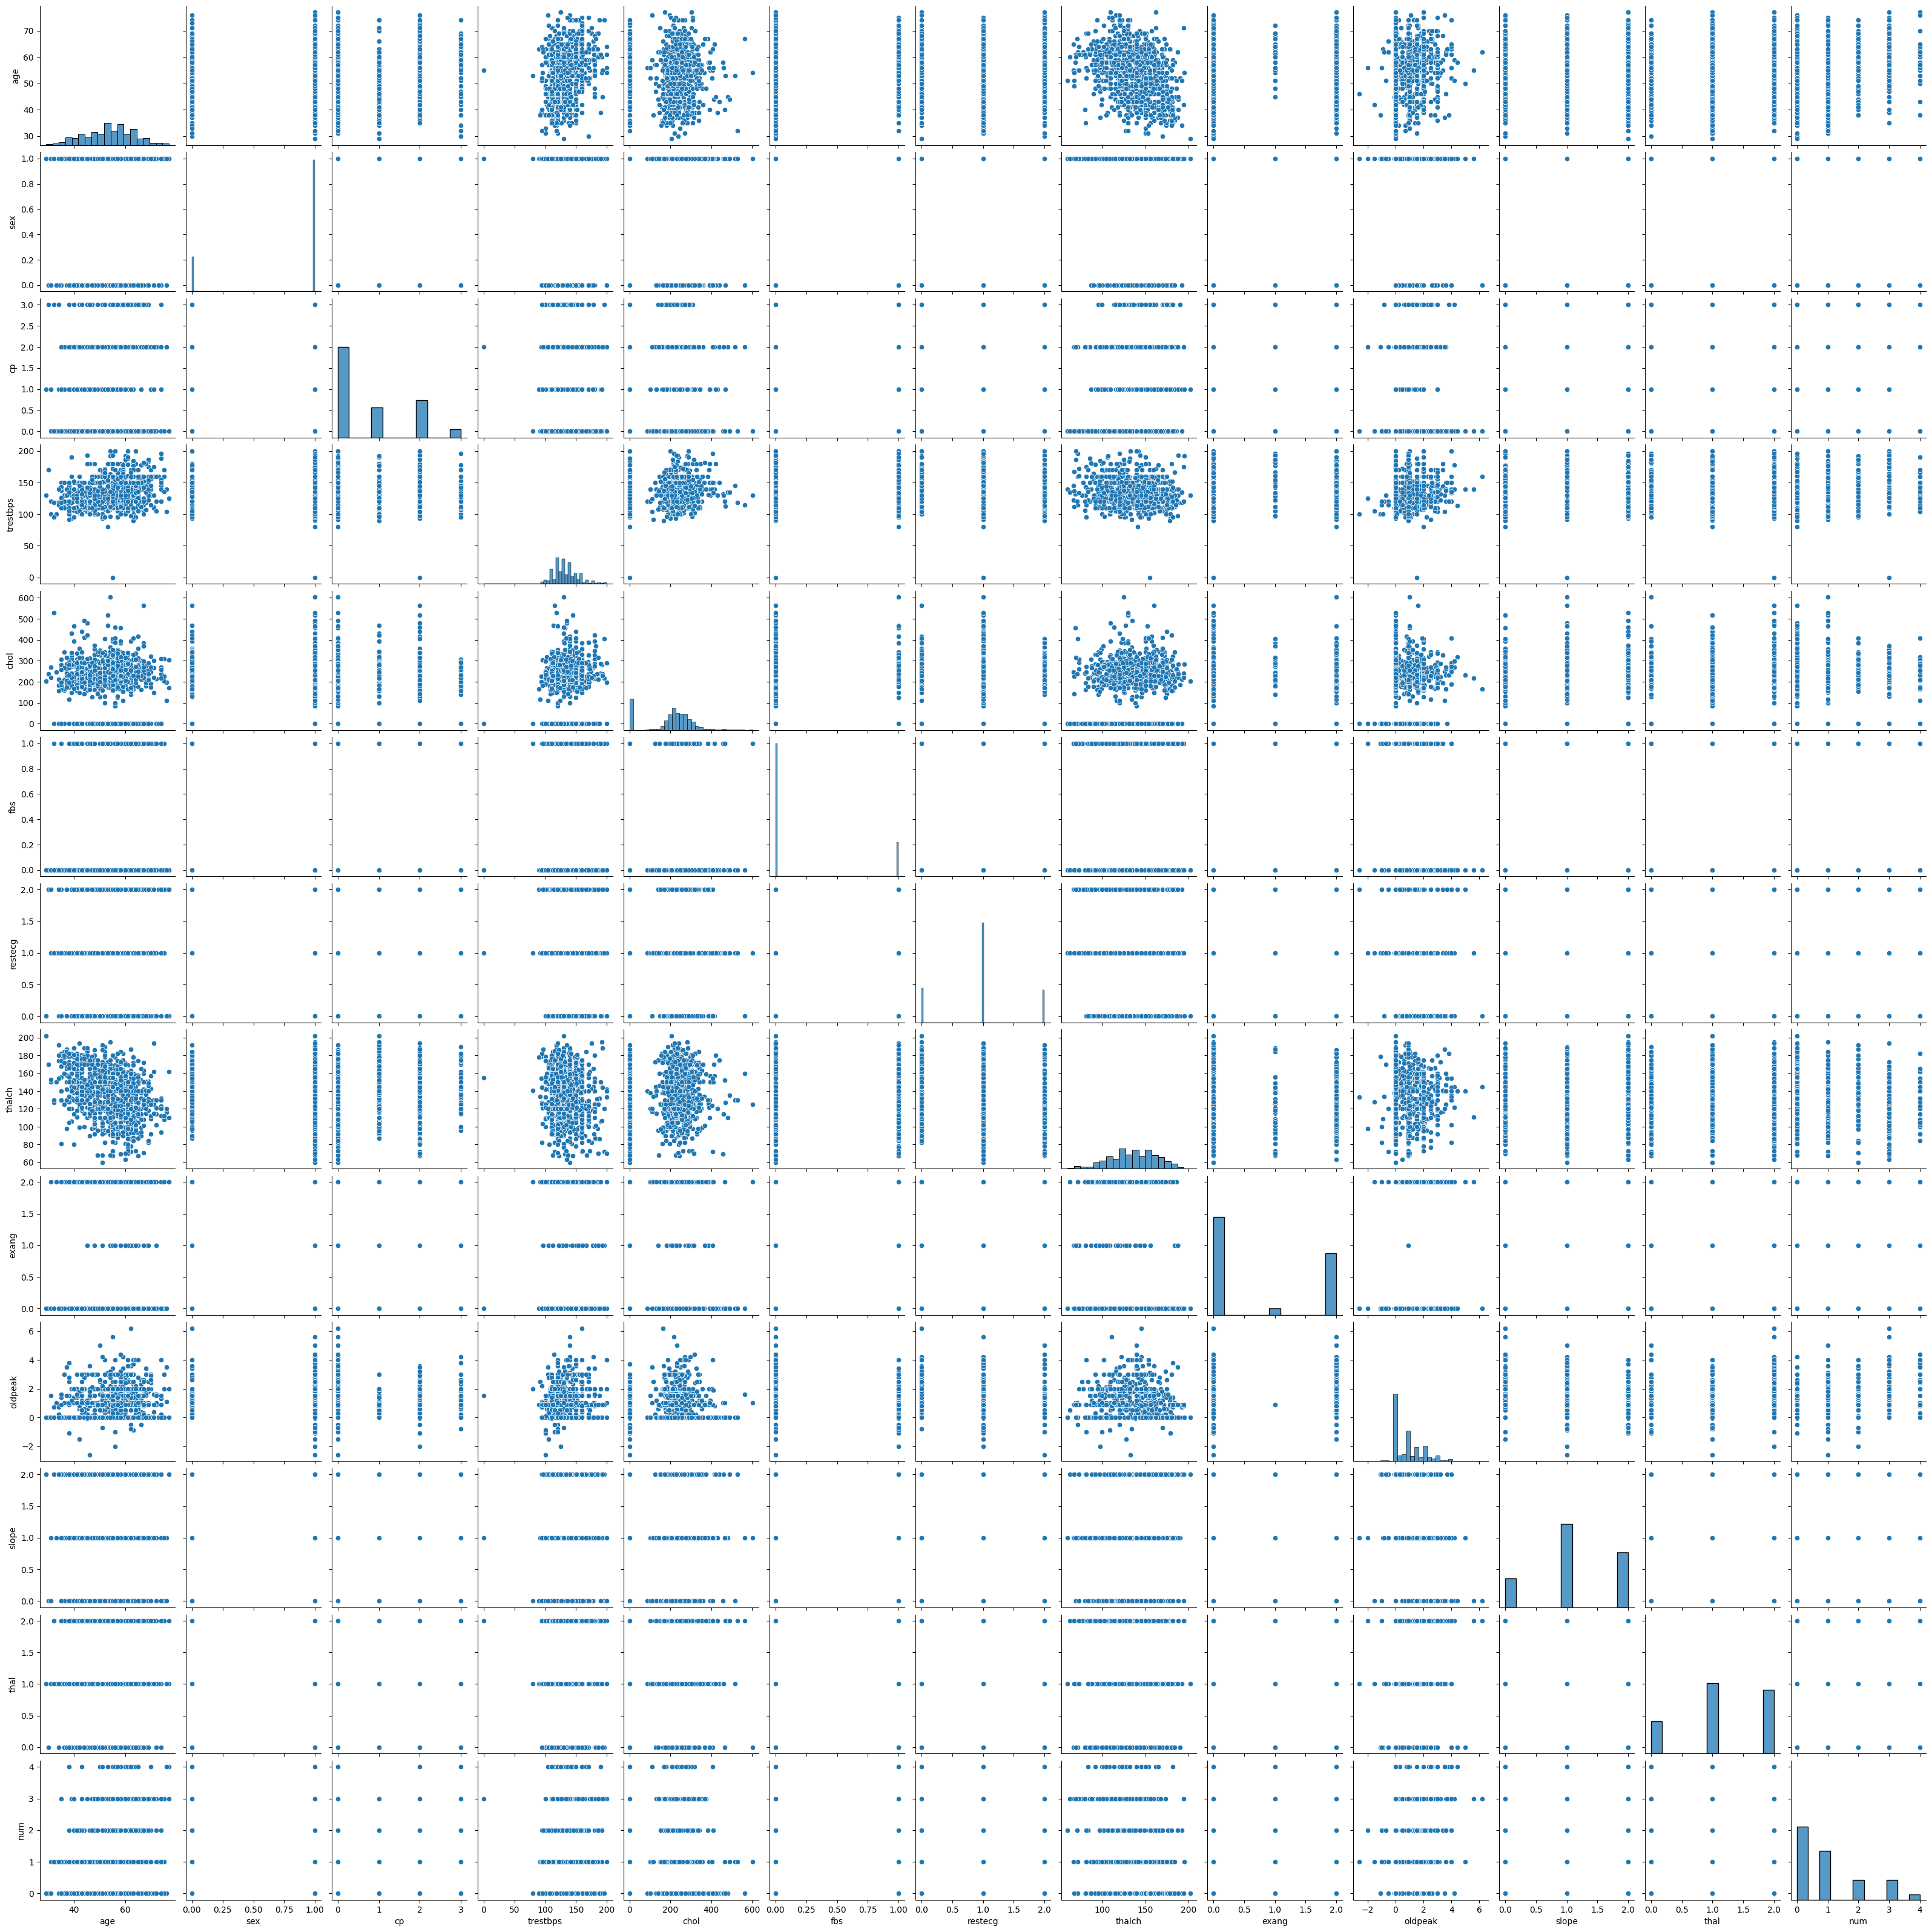

In [21]:
#pairplot

sns.pairplot(data)
plt.show()

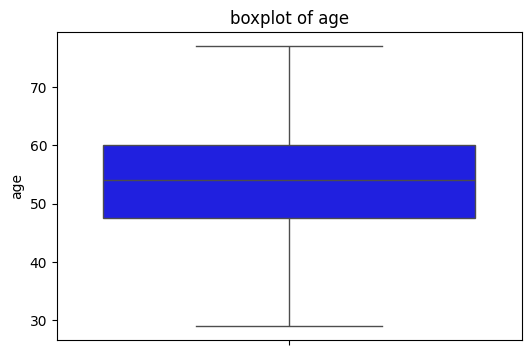

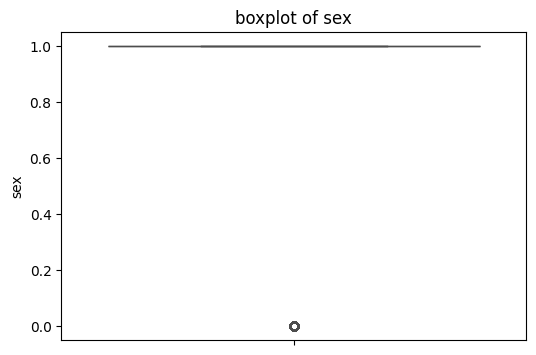

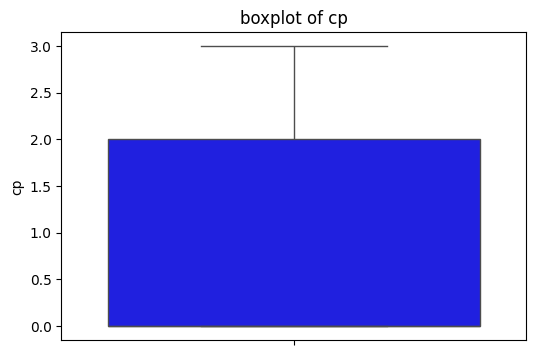

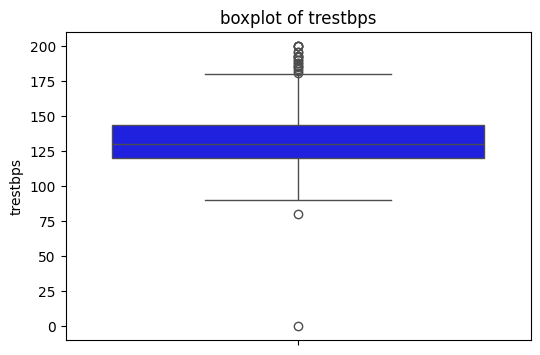

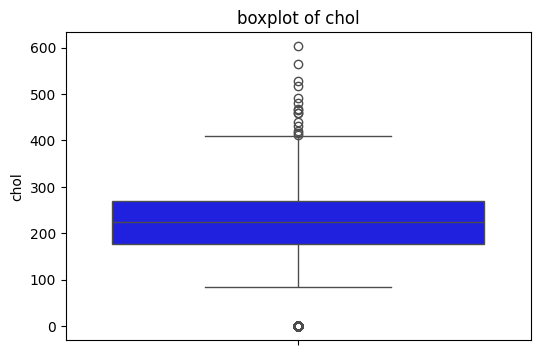

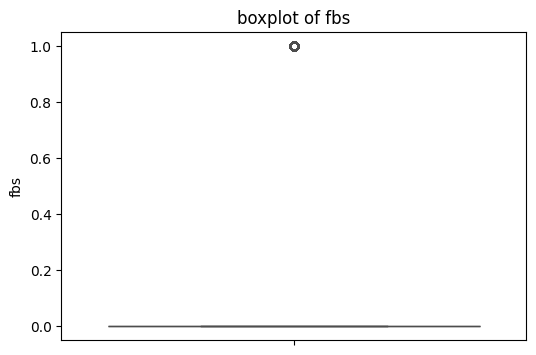

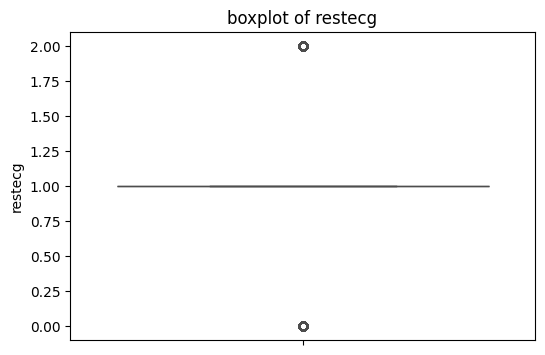

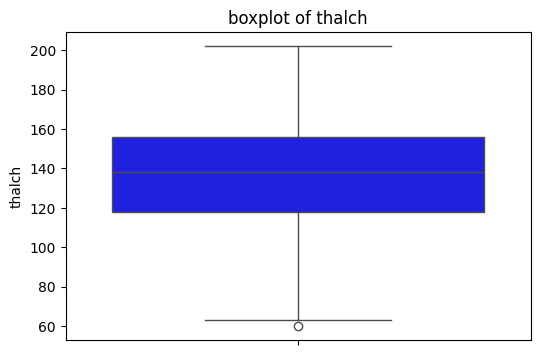

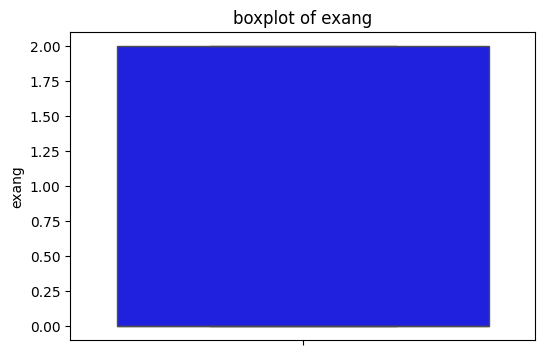

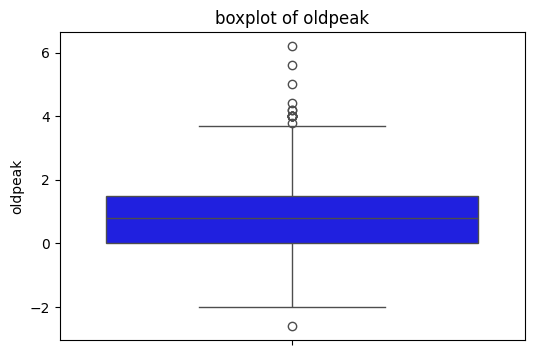

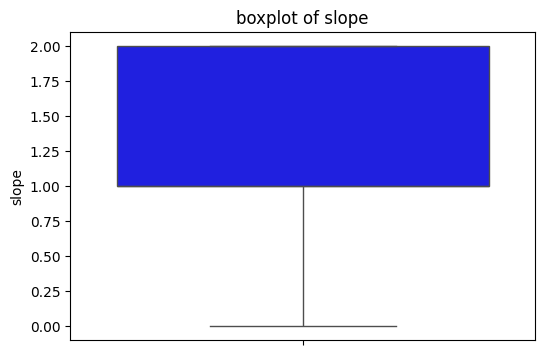

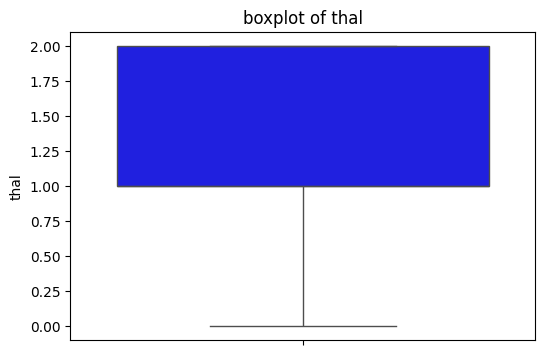

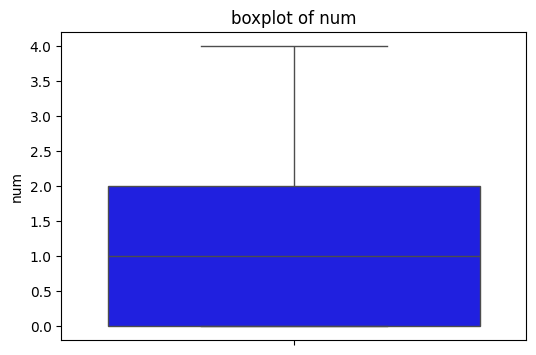

In [22]:
#Create boxplots for to identify outliers.

for col in data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=data[col],color='blue')
    plt.title(f'boxplot of {col}')
    plt.show()

### 4. Decision Tree Classification:

#### Split the dataset into training and testing sets

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = data.drop('num',axis=1)
y = data['num']

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((725, 12), (182, 12), (725,), (182,))

#### Implement a Decision Tree Classification model 

In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
dtree = DecisionTreeClassifier(max_depth=6,max_leaf_nodes=10,criterion='entropy')
dtree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [28]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [29]:
def evaluate_clf(y,yhat):
    cm = confusion_matrix(y,yhat)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,annot=True,fmt='d',cmap='mako',cbar=False)
    plt.show()
    print(classification_report(y,yhat,zero_division=0))

In [30]:
# evaluate the model on training data
yhat_train = dtree.predict(X_train)

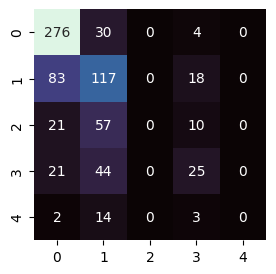

              precision    recall  f1-score   support

           0       0.68      0.89      0.77       310
           1       0.45      0.54      0.49       218
           2       0.00      0.00      0.00        88
           3       0.42      0.28      0.33        90
           4       0.00      0.00      0.00        19

    accuracy                           0.58       725
   macro avg       0.31      0.34      0.32       725
weighted avg       0.48      0.58      0.52       725



In [31]:
evaluate_clf(y_train,yhat_train)

In [32]:
# evaluate the model on testing data
yhat_test = dtree.predict(X_test)

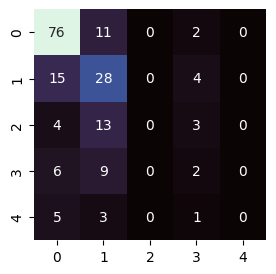

              precision    recall  f1-score   support

           0       0.72      0.85      0.78        89
           1       0.44      0.60      0.50        47
           2       0.00      0.00      0.00        20
           3       0.17      0.12      0.14        17
           4       0.00      0.00      0.00         9

    accuracy                           0.58       182
   macro avg       0.26      0.31      0.28       182
weighted avg       0.48      0.58      0.52       182



In [33]:
evaluate_clf(y_test,yhat_test)

### 5. Hyperparameter Tuning:

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
param_grid = {
    'max_depth' : [None,3,5,7,10,15],
    'min_samples_split' : [2,5,10,20],
    'criterion' : ['gini','entropy']
}

In [36]:
dt = DecisionTreeClassifier(random_state=42)

In [37]:
grid_search = GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

In [38]:
print('best parameters:',grid_search.best_params_)
print('best cross-validation accuracy:',grid_search.best_score_)

best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
best cross-validation accuracy: 0.5462068965517242


In [39]:
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

In [40]:
print('Test accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred, zero_division=0))

Test accuracy: 0.5769230769230769

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.87      0.79        89
           1       0.42      0.57      0.49        47
           2       0.00      0.00      0.00        20
           3       0.09      0.06      0.07        17
           4       0.00      0.00      0.00         9

    accuracy                           0.58       182
   macro avg       0.25      0.30      0.27       182
weighted avg       0.47      0.58      0.52       182



### 6. Model Evaluation and Analysis:

In [41]:
!pip install yellowbrick

In [42]:
from yellowbrick.classifier import ROCAUC

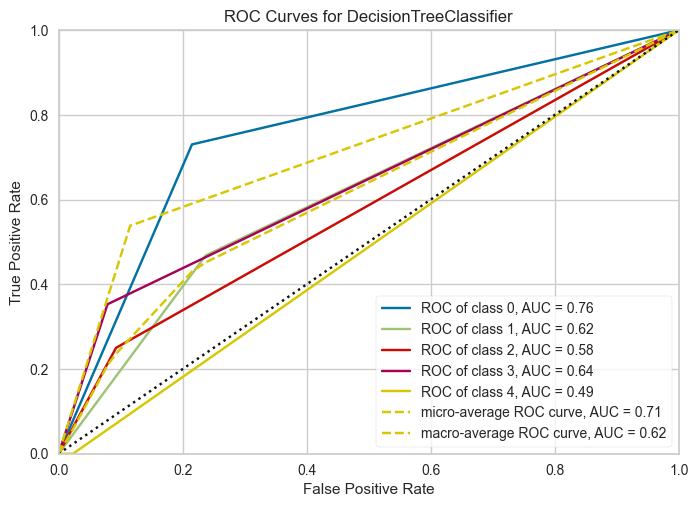

<Axes: title={'center': 'ROC Curves for DecisionTreeClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [47]:
from sklearn.tree import DecisionTreeClassifier
from yellowbrick.classifier import ROCAUC

model = DecisionTreeClassifier()

visualizer = ROCAUC(model, classes=[0,1,2,3,4], micro=True, macro=True, force_model=True)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

In [48]:
from sklearn.tree import plot_tree

In [50]:
fnames = X.columns.values
fnames

array(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal'], dtype=object)

In [51]:
cnames = data['num'].unique()
cnames = [str(c) for c in cnames]
cnames

['0', '1', '2', '3', '4']

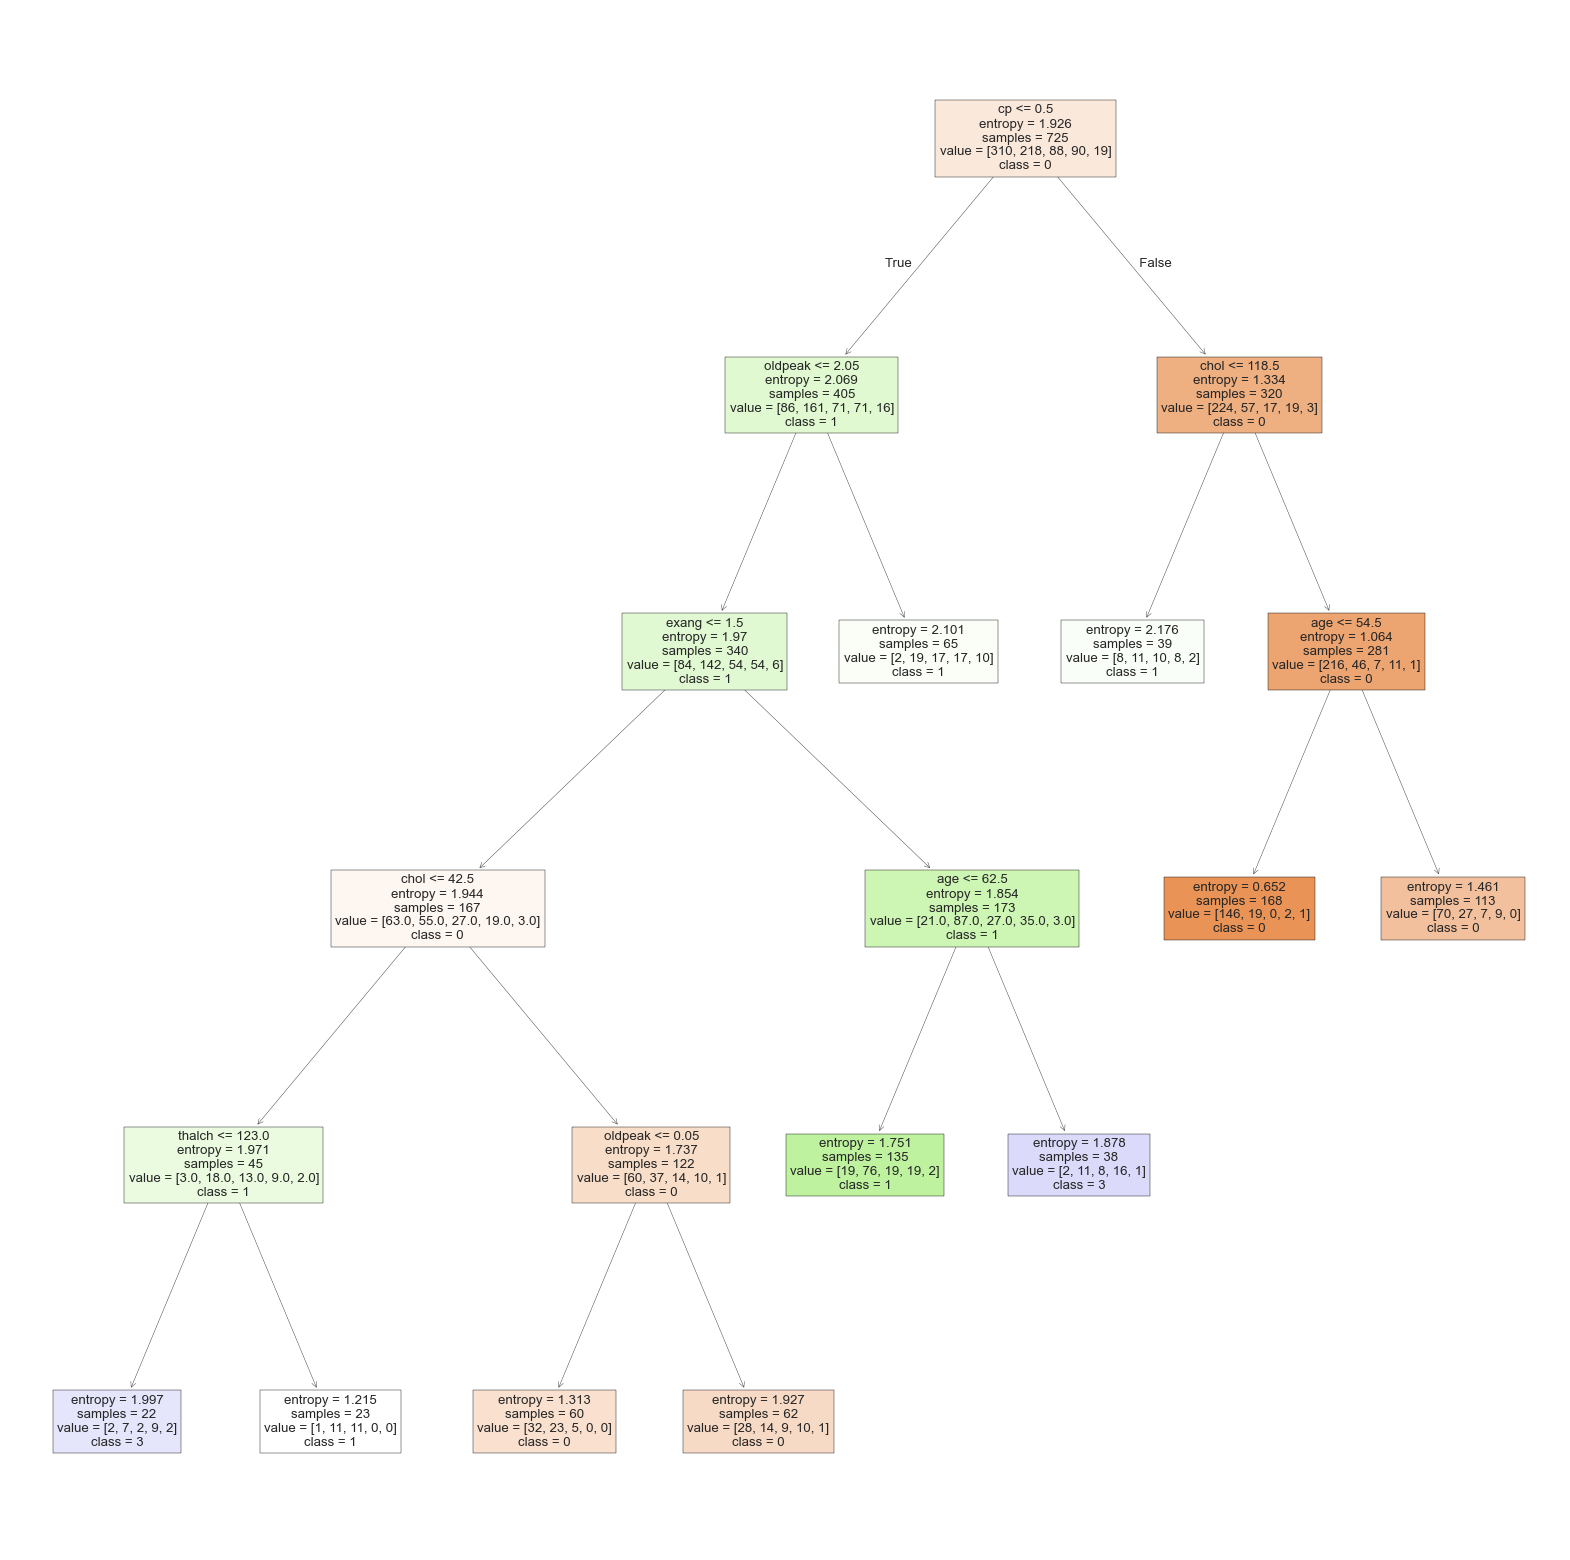

In [52]:
plt.figure(figsize=(20,20))
plot_tree(dtree,class_names=cnames,feature_names=fnames,filled=True)
plt.show()

## Interview Questions:

### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
    common decision tree hyperparameters include max_depth (limits tree depth,shallow-> underfit, deep->overfit), min_samples_split and min_samples_leaf(control node/leaf size, small->overfit,large -> underfit), and criterion(gini or entropy for split quality) 

### 2. What is the difference between the Label encoding and One-hot encoding?
    label encoding assigns a unique numeric value to each category(e.g, red=0,blue=1,green=2) which can imply an order that dosen't exist.
    one-hot encoding creates separate binary columns for each category, avoding order but increasing dimensionality